In [1]:
import pandas as pd
import numpy as np
from functions import *
from sklearn.utils import shuffle
X_train_orig = pd.read_csv('../data/X_train.csv', index_col='id')
X_train_filtered = filter_signal(X_train_orig)
X_test_orig = pd.read_csv('../data/X_test.csv', index_col='id')
X_test_filtered = filter_signal(X_test_orig)
y_train_orig = pd.read_csv('../data/y_train.csv', index_col='id')

In [2]:
print("Median number of entries in each times series: ", np.median(np.sum(X_train_filtered.notna(), axis=1)))
print("Minimum number of entries in each times series: ", np.min(np.sum(X_train_filtered.notna(), axis=1)))
print("Size of training data: ", len(X_train_orig))
print(y_train_orig.value_counts())

Median number of entries in each times series:  8370.0
Minimum number of entries in each times series:  2490
Size of training data:  5117
y
0    3030
2    1474
1     443
3     170
dtype: int64


In [72]:
#Padding the sequence with the values in last row to max length
to_pad = 8400 # cut the sequence and impute the missing entries until all have this length
steps = 20 # to reduce time series length on every timepoint is taken
split = 4000 # to create test set with known label
n_1 = 700 # for upsampling
n_2 = 2000 
n_3 = 500

# choose the data to actually train on (after padding)
X_train = X_train_filtered 
X_test = X_test_filtered
y_train = y_train_orig

In [73]:
# shuffle data
X_train, y_train = shuffle(X_train, y_train, random_state=42)

X_train_padded = pd.DataFrame(np.ones((len(X_train),to_pad)))
for i in range(len(X_train)):
    one_seq = X_train.iloc[i,0:to_pad].dropna()
    len_one_seq = len(one_seq)
    last_val = one_seq[-1]
    n = to_pad - len_one_seq
   
    to_concat = np.repeat(one_seq[-1], n)
    new_one_seq = np.concatenate([one_seq, to_concat])
    X_train_padded.iloc[i,:] = new_one_seq
X_train_padded = X_train_padded.iloc[:,::steps]

X_test_padded = pd.DataFrame(np.ones((len(X_test),to_pad)))
for i in range(len(X_test)):
    one_seq = X_test.iloc[i,0:to_pad].dropna()
    len_one_seq = len(one_seq)
    last_val = one_seq[-1]
    n = to_pad - len_one_seq
   
    to_concat = np.repeat(one_seq[-1], n)
    new_one_seq = np.concatenate([one_seq, to_concat])
    X_test_padded.iloc[i,:] = new_one_seq
X_test_padded = X_test_padded.iloc[:,::steps]

# creat test set with labels
test = X_train_padded.iloc[split:,:] #  X_train.iloc[split:,:]
test_target = y_train.iloc[split:,:]
train = X_train_padded.iloc[:split,:] #  X_train.iloc[:split,:]
train_target = y_train.iloc[:split]

# validation sample actually not needed for second model
# from sklearn.model_selection import train_test_split
# train, validation, train_target, validation_target = train_test_split(X_train_padded, y_train, test_size=0.33, random_state=42)

# balance classes
# from sklearn.utils import resample
# df_1=train[np.array(train_target["y"]==1)]
# df_2=train[np.array(train_target["y"]==2)]
# df_3=train[np.array(train_target["y"]==3)]
# df_0=train[np.array(train_target["y"]==0)]

# df_1_upsample=resample(df_1,replace=True,n_samples=n_1,random_state=123)
# df_2_upsample=resample(df_2,replace=True,n_samples=n_2,random_state=124)
# df_3_upsample=resample(df_3,replace=True,n_samples=n_3,random_state=125)

# train=pd.concat([df_0,df_1_upsample,df_2_upsample,df_3_upsample],axis=0)
# train_target=pd.DataFrame([0]*len(df_0)+[1]*n_1+[2]*n_2+[3]*n_3)

# shuffle data
idx = np.random.permutation(len(train))
train = train.iloc[idx]
train_target = train_target.iloc[idx]

# get data in right dimension
train = np.array(train).reshape((train.shape[0], train.shape[1], 1))
# validation = np.array(validation).reshape((validation.shape[0], validation.shape[1], 1))
test = np.array(test).reshape((test.shape[0], test.shape[1], 1))

In [74]:
print(train_target.value_counts())
print(test_target.value_counts())

y
0    2375
2    1163
1     327
3     135
dtype: int64
y
0    655
2    311
1    116
3     35
dtype: int64


In [75]:
# cnn lstm model
from keras.models import Sequential
from keras.layers import Dense, Activation, Add, Softmax
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import LSTM
from keras.layers import TimeDistributed
from keras.layers import Normalization
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.optimizers import Adam
from keras.models import load_model
from keras.callbacks import ModelCheckpoint

In [76]:
# classes = len(np.unique(train_target))

# model = Sequential()
# model.add(LSTM(50, input_shape=(train.shape[1], 1)))
# model.add(Dropout(0.5))
# model.add(Dense(100, activation='relu'))
# model.add(Dense(classes, activation='softmax'))
# model.summary()

In [77]:
# adam = Adam(learning_rate=0.001)
# chk = ModelCheckpoint('best_model.pkl', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
# model.compile(loss='sparse_categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
# model.fit(train, train_target, epochs=10, batch_size=200, callbacks=[chk], validation_data=(validation,validation_target))


In [78]:
# #loading the model and checking accuracy on the test data
# model = load_model('best_model.pkl')

# from sklearn.metrics import f1_score
# predict_x=model.predict(test) 
# classes_x=np.argmax(predict_x,axis=1)
# f1_score(test_target, classes_x, average='micro')

In [79]:
from tensorflow import keras
def make_CNN(input_shape):
    input_layer = keras.layers.Input(input_shape)
    normalisation_layer = Normalization()(input_layer)

    conv1 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(normalisation_layer) 
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)

    conv2 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv1)
    conv2 = keras.layers.BatchNormalization()(conv2)
    conv2 = keras.layers.ReLU()(conv2)
    
    conv3 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv2)
    conv3 = keras.layers.BatchNormalization()(conv3)
    conv3 = keras.layers.ReLU()(conv3)

    conv4 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv3)
    conv4 = keras.layers.BatchNormalization()(conv4)
    conv4 = keras.layers.ReLU()(conv4)

    # conv5 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv4)
    # conv5 = keras.layers.BatchNormalization()(conv5)
    # conv5 = keras.layers.ReLU()(conv5)

    # conv6 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv5)
    # conv6 = keras.layers.BatchNormalization()(conv6)
    # conv6 = keras.layers.ReLU()(conv6)

    # conv7 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv6)
    # conv7 = keras.layers.BatchNormalization()(conv7)
    # conv7 = keras.layers.ReLU()(conv7)

    gap = keras.layers.GlobalAveragePooling1D()(conv4)

    dense1 = keras.layers.Dense(50, activation='relu')(gap)
    dense2 = keras.layers.Dense(50, activation='relu')(dense1)
    dropout2 = keras.layers.Dropout(0.5)(dense2)
    dense3 = keras.layers.Dense(50, activation='relu')(dropout2)
    # dropout = keras.layers.Dropout(0.5)(dense2)

    output_layer = keras.layers.Dense(4, activation="softmax")(dense3)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)

In [80]:
def make_arvix(input_shape):
    input_layer = keras.layers.Input(input_shape)
    normalisation_layer = Normalization()(input_layer)
    C = Conv1D(filters=32, kernel_size=5, strides=1)(normalisation_layer)

    C11 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(C)
    A11 = Activation("relu")(C11)
    C12 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A11)
    S11 = Add()([C12, C])
    A12 = Activation("relu")(S11)
    M11 = MaxPooling1D(pool_size=5, strides=2)(A12)


    C21 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M11)
    A21 = Activation("relu")(C21)
    C22 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A21)
    S21 = Add()([C22, M11])
    A22 = Activation("relu")(S21) # S21?
    M21 = MaxPooling1D(pool_size=5, strides=2)(A22)


    C31 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M21)
    A31 = Activation("relu")(C31)
    C32 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A31)
    S31 = Add()([C32, M21])
    A32 = Activation("relu")(S31)
    M31 = MaxPooling1D(pool_size=5, strides=2)(A32)


    C41 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M31)
    A41 = Activation("relu")(C41)
    C42 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A41)
    S41 = Add()([C42, M31])
    A42 = Activation("relu")(S41)
    M41 = MaxPooling1D(pool_size=5, strides=2)(A42)


    C51 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M41)
    A51 = Activation("relu")(C51)
    C52 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A51)
    S51 = Add()([C52, M41])
    A52 = Activation("relu")(S51)
    M51 = MaxPooling1D(pool_size=5, strides=2)(A52)

    F1 = Flatten()(M51)

    D1 = Dense(32)(F1)
    A6 = Activation("relu")(D1)
    D2 = Dense(32)(A6)
    D3 = Dense(4)(D2)
    output_layer = Softmax()(D3)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)

In [81]:
def make_LSTM(input_shape):
    input_layer = keras.layers.Input(input_shape)
    normalisation_layer = Normalization()(input_layer)

    conv1 = keras.layers.Conv1D(filters=64, kernel_size=10, padding="same", kernel_regularizer='l2')(normalisation_layer) 
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)

    # conv2 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv1)
    # conv2 = keras.layers.BatchNormalization()(conv2)
    # conv2 = keras.layers.ReLU()(conv2)
    
    # conv3 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv2)
    # conv3 = keras.layers.BatchNormalization()(conv3)
    # conv3 = keras.layers.ReLU()(conv3)

    # conv4 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv3)
    # conv4 = keras.layers.BatchNormalization()(conv4)
    # conv4 = keras.layers.ReLU()(conv4)

    gap = keras.layers.MaxPooling1D(pool_size=2)(conv1)

    LSTM1 = keras.layers.LSTM(50)(gap)

    dense1 = keras.layers.Dense(50, activation='relu')(LSTM1)
    dense2 = keras.layers.Dense(50, activation='relu')(dense1)

    output_layer = keras.layers.Dense(4, activation="softmax")(dense2)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)


In [82]:
model1= make_CNN(input_shape=train.shape[1:]) # make_CNN(input_shape=train.shape[1:])
# keras.utils.plot_model(model, show_shapes=True)
model1.summary()

Model: "model_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_8 (InputLayer)         [(None, 420, 1)]          0         
_________________________________________________________________
normalization_7 (Normalizati (None, 420, 1)            3         
_________________________________________________________________
conv1d_32 (Conv1D)           (None, 420, 64)           384       
_________________________________________________________________
batch_normalization_21 (Batc (None, 420, 64)           256       
_________________________________________________________________
re_lu_21 (ReLU)              (None, 420, 64)           0         
_________________________________________________________________
conv1d_33 (Conv1D)           (None, 420, 64)           20544     
_________________________________________________________________
batch_normalization_22 (Batc (None, 420, 64)           256 

In [83]:
epochs = 500
batch_size = 32

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.00001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1),
]
model1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
history = model1.fit(
    train,
    train_target,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/500


2021-12-05 17:45:52.817204: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


 97/100 [============================>.] - ETA: 0s - loss: 1.8656 - sparse_categorical_accuracy: 0.5670

2021-12-05 17:45:54.907368: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


100/100 [==============================] - 3s 19ms/step - loss: 1.8427 - sparse_categorical_accuracy: 0.5706 - val_loss: 1.2334 - val_sparse_categorical_accuracy: 0.6337
Epoch 2/500
100/100 [==============================] - 2s 16ms/step - loss: 1.0827 - sparse_categorical_accuracy: 0.5972 - val_loss: 1.0524 - val_sparse_categorical_accuracy: 0.6425
Epoch 3/500
100/100 [==============================] - 2s 17ms/step - loss: 0.9782 - sparse_categorical_accuracy: 0.6106 - val_loss: 1.1079 - val_sparse_categorical_accuracy: 0.5962
Epoch 4/500
100/100 [==============================] - 2s 16ms/step - loss: 0.9394 - sparse_categorical_accuracy: 0.6241 - val_loss: 0.9159 - val_sparse_categorical_accuracy: 0.6637
Epoch 5/500
100/100 [==============================] - 2s 16ms/step - loss: 0.9324 - sparse_categorical_accuracy: 0.6287 - val_loss: 1.0201 - val_sparse_categorical_accuracy: 0.6413
Epoch 6/500
100/100 [==============================] - 2s 17ms/step - loss: 0.9014 - sparse_categorica

In [84]:
model = keras.models.load_model("best_model.h5")

test_loss, test_acc = model.evaluate(test,test_target)

print("Test accuracy", test_acc)
print("Test loss", test_loss)

 6/35 [====>.........................] - ETA: 0s - loss: 0.7914 - sparse_categorical_accuracy: 0.7292

2021-12-05 17:50:23.411076: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


35/35 [==============================] - 1s 10ms/step - loss: 0.6330 - sparse_categorical_accuracy: 0.7672
Test accuracy 0.767233669757843
Test loss 0.632983922958374


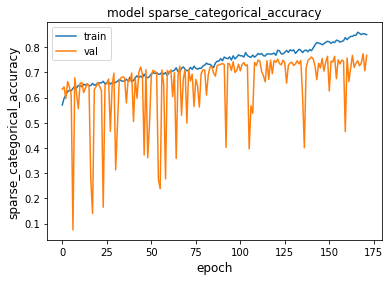

In [85]:
metric = "sparse_categorical_accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

In [86]:
from sklearn.metrics import f1_score
predict_x=model.predict(test) 
classes_x=np.argmax(predict_x,axis=1)
f1_score(test_target, classes_x, average='micro')

2021-12-05 17:50:24.036526: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


0.7672336615935542

In [87]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(test_target, classes_x))
print("Confusion Matrix:\n", confusion_matrix(test_target, classes_x))

              precision    recall  f1-score   support

           0       0.78      0.94      0.85       655
           1       0.76      0.67      0.72       116
           2       0.76      0.43      0.55       311
           3       0.57      0.74      0.64        35

    accuracy                           0.77      1117
   macro avg       0.72      0.70      0.69      1117
weighted avg       0.77      0.77      0.75      1117

Confusion Matrix:
 [[618   5  20  12]
 [ 16  78  20   2]
 [152  18 135   6]
 [  6   1   2  26]]


# Predict

In [19]:
# predict final test set
y_test = pd.DataFrame({'id' : range(X_test_padded.shape[0])})
predict_x=model.predict(X_test_padded) 
y_test['y'] = np.argmax(predict_x,axis=1)
y_test.to_csv('../out/y_test.csv', index=False)

2021-12-04 10:12:26.689073: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


In [20]:
print(y_test['y'].value_counts())

0    2227
2     696
1     397
3      91
Name: y, dtype: int64


# Get only heartbeats

In [21]:
X_train_beats = np.empty((0, 180))
y_train_beats = []
for i in range(len(X_train_filtered)):
    signal = X_train_filtered.loc[i].dropna().to_numpy(dtype='float32')
    r_peaks = ecg.engzee_segmenter(signal, 300)['rpeaks']
    beats = ecg.extract_heartbeats(signal, r_peaks, 300)['templates']
    temp1 = np.zeros((len(beats),180))
    for b in range(len(beats)):
        temp1[b,:] = beats[b]
    
    X_train_beats = np.vstack([X_train_beats, temp1])
    y_train_beats = np.hstack([y_train_beats, np.repeat(y_train_orig.iloc[i,0], len(beats))])

X_train_beats, y_train_beats = shuffle(X_train_beats, y_train_beats, random_state=42)

In [22]:
from sklearn.model_selection import train_test_split
train_beats, test_beats, train_beats_target, test_beats_target = train_test_split(X_train_beats, y_train_beats, test_size=0.33, random_state=42)

In [23]:
train_beats = np.expand_dims(train_beats, 2)
test_beats = np.expand_dims(test_beats, 2)

In [24]:
# model= make_arvix(input_shape=train_beats.shape[1:]) # make_CNN(input_shape=train.shape[1:])
# # keras.utils.plot_model(model, show_shapes=True)
# model.summary()

In [25]:
model_arvix= make_arvix(input_shape=train_beats.shape[1:]) # make_CNN(input_shape=train.shape[1:])
# keras.utils.plot_model(model, show_shapes=True)
# model.summary()

epochs = 500
batch_size = 200

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.00001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1),
]
model_arvix.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
history = model_arvix.fit(
    train_beats,
    train_beats_target,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/500


2021-12-04 10:17:27.593181: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


480/480 [==============================] - ETA: 0s - loss: 4.3534 - sparse_categorical_accuracy: 0.5225

2021-12-04 10:17:36.010496: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


480/480 [==============================] - 10s 19ms/step - loss: 4.3534 - sparse_categorical_accuracy: 0.5225 - val_loss: 1.1701 - val_sparse_categorical_accuracy: 0.5880
Epoch 2/500
  4/480 [..............................] - ETA: 8s - loss: 1.1148 - sparse_categorical_accuracy: 0.5612 

/Users/juliusc/miniforge3/lib/python3.9/site-packages/keras/utils/generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


480/480 [==============================] - 9s 18ms/step - loss: 1.0199 - sparse_categorical_accuracy: 0.5847 - val_loss: 0.9511 - val_sparse_categorical_accuracy: 0.6058
Epoch 3/500
480/480 [==============================] - 9s 18ms/step - loss: 0.9538 - sparse_categorical_accuracy: 0.5980 - val_loss: 0.9378 - val_sparse_categorical_accuracy: 0.6074
Epoch 4/500
480/480 [==============================] - 9s 18ms/step - loss: 0.9197 - sparse_categorical_accuracy: 0.6080 - val_loss: 0.9358 - val_sparse_categorical_accuracy: 0.6032
Epoch 5/500
480/480 [==============================] - 9s 18ms/step - loss: 0.9003 - sparse_categorical_accuracy: 0.6123 - val_loss: 0.8917 - val_sparse_categorical_accuracy: 0.6201
Epoch 6/500
480/480 [==============================] - 9s 18ms/step - loss: 0.8870 - sparse_categorical_accuracy: 0.6181 - val_loss: 0.8873 - val_sparse_categorical_accuracy: 0.6251
Epoch 7/500
480/480 [==============================] - 9s 18ms/step - loss: 0.8715 - sparse_categorica

In [26]:
model_CNN= make_CNN(input_shape=train_beats.shape[1:]) # make_CNN(input_shape=train.shape[1:])
# keras.utils.plot_model(model, show_shapes=True)
# model.summary()

epochs = 500
batch_size = 200

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.00001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1),
]
model_CNN.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
history = model_CNN.fit(
    train_beats,
    train_beats_target,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/500


2021-12-04 10:32:56.686778: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


480/480 [==============================] - ETA: 0s - loss: 1.1348 - sparse_categorical_accuracy: 0.5787

2021-12-04 10:33:07.191431: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


480/480 [==============================] - 12s 23ms/step - loss: 1.1348 - sparse_categorical_accuracy: 0.5787 - val_loss: 1.0370 - val_sparse_categorical_accuracy: 0.5841
Epoch 2/500
480/480 [==============================] - 11s 23ms/step - loss: 0.9477 - sparse_categorical_accuracy: 0.5930 - val_loss: 1.0701 - val_sparse_categorical_accuracy: 0.5679
Epoch 3/500
480/480 [==============================] - 11s 23ms/step - loss: 0.9357 - sparse_categorical_accuracy: 0.5985 - val_loss: 1.6418 - val_sparse_categorical_accuracy: 0.3075
Epoch 4/500
480/480 [==============================] - 11s 22ms/step - loss: 0.9274 - sparse_categorical_accuracy: 0.6017 - val_loss: 1.0472 - val_sparse_categorical_accuracy: 0.5421
Epoch 5/500
480/480 [==============================] - 11s 22ms/step - loss: 0.9219 - sparse_categorical_accuracy: 0.6057 - val_loss: 0.9561 - val_sparse_categorical_accuracy: 0.5824
Epoch 6/500
480/480 [==============================] - 11s 23ms/step - loss: 0.9138 - sparse_cate

In [27]:
model_LSTM= make_LSTM(input_shape=train_beats.shape[1:]) # make_CNN(input_shape=train.shape[1:])
# keras.utils.plot_model(model, show_shapes=True)
# model.summary()

epochs = 500
batch_size = 200

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.00001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1),
]
model_LSTM.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
history = model_LSTM.fit(
    train_beats,
    train_beats_target,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/500


2021-12-04 11:47:42.968825: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.
2021-12-04 11:47:43.101057: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.
2021-12-04 11:47:43.382674: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


480/480 [==============================] - ETA: 0s - loss: 1.0036 - sparse_categorical_accuracy: 0.5766

2021-12-04 11:48:06.035559: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.
2021-12-04 11:48:06.085334: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


480/480 [==============================] - 26s 51ms/step - loss: 1.0036 - sparse_categorical_accuracy: 0.5766 - val_loss: 0.9687 - val_sparse_categorical_accuracy: 0.5881
Epoch 2/500
480/480 [==============================] - 24s 50ms/step - loss: 0.9612 - sparse_categorical_accuracy: 0.5880 - val_loss: 0.9791 - val_sparse_categorical_accuracy: 0.5848
Epoch 3/500
480/480 [==============================] - 24s 50ms/step - loss: 0.9446 - sparse_categorical_accuracy: 0.5903 - val_loss: 0.9307 - val_sparse_categorical_accuracy: 0.5952
Epoch 4/500
480/480 [==============================] - 24s 50ms/step - loss: 0.9358 - sparse_categorical_accuracy: 0.5967 - val_loss: 0.9285 - val_sparse_categorical_accuracy: 0.5986
Epoch 5/500
480/480 [==============================] - 24s 50ms/step - loss: 0.9389 - sparse_categorical_accuracy: 0.6028 - val_loss: 0.9376 - val_sparse_categorical_accuracy: 0.6102
Epoch 6/500
480/480 [==============================] - 24s 50ms/step - loss: 0.9455 - sparse_cate

In [28]:
predict_x=model.predict(X_train_beats) 
pd.DataFrame(np.argmax(predict_x,axis=1)).value_counts()

ValueError: in user code:

    /Users/juliusc/miniforge3/lib/python3.9/site-packages/keras/engine/training.py:1586 predict_function  *
        return step_function(self, iterator)
    /Users/juliusc/miniforge3/lib/python3.9/site-packages/keras/engine/training.py:1576 step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    /Users/juliusc/miniforge3/lib/python3.9/site-packages/tensorflow/python/distribute/distribute_lib.py:1286 run
        return self._extended.call_for_each_replica(fn, args=args, kwargs=kwargs)
    /Users/juliusc/miniforge3/lib/python3.9/site-packages/tensorflow/python/distribute/distribute_lib.py:2849 call_for_each_replica
        return self._call_for_each_replica(fn, args, kwargs)
    /Users/juliusc/miniforge3/lib/python3.9/site-packages/tensorflow/python/distribute/distribute_lib.py:3632 _call_for_each_replica
        return fn(*args, **kwargs)
    /Users/juliusc/miniforge3/lib/python3.9/site-packages/keras/engine/training.py:15

In [29]:
model = model_arvix # keras.models.load_model("best_model.h5")

test_loss, test_acc = model.evaluate(test_beats,test_beats_target)

print("Test accuracy", test_acc)
print("Test loss", test_loss)

1845/1845 [==============================] - 11s 6ms/step - loss: 1.0010 - sparse_categorical_accuracy: 0.7576
Test accuracy 0.7576107382774353
Test loss 1.001016616821289


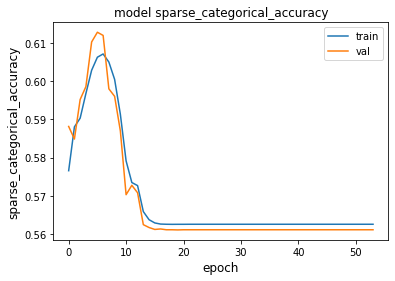

In [30]:
metric = "sparse_categorical_accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

In [31]:
from sklearn.metrics import f1_score
predict_x=model.predict(test_beats) 
classes_x=np.argmax(predict_x,axis=1)
f1_score(test_beats_target, classes_x, average='micro')

2021-12-05 17:14:21.527009: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


0.757610665943858

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(test_beats_target, classes_x))
print("Confusion Matrix:\n", confusion_matrix(test_beats_target, classes_x))

              precision    recall  f1-score   support

         0.0       0.81      0.86      0.83     33307
         1.0       0.66      0.62      0.64      6116
         2.0       0.71      0.66      0.68     18074
         3.0       0.42      0.33      0.37      1532

    accuracy                           0.76     59029
   macro avg       0.65      0.62      0.63     59029
weighted avg       0.75      0.76      0.75     59029

Confusion Matrix:
 [[28556   909  3469   373]
 [ 1271  3771   981    93]
 [ 5011   931 11888   244]
 [  605    85   336   506]]
